<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg", align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.875 · Deep Learning · PEC3</p>
<p style="margin: 0; text-align:right;">2025-2 · Máster universitario en Ciencia de datos (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicación</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>


# PEC 3: Transformers con Pytorch


<u>Consideraciones generales</u>:

- Esta PEC debe realizarse de forma **estrictamente individual**. Cualquier indicio de copia será penalizado con un suspenso (D) para todas las partes implicadas y la posible evaluación negativa de la asignatura de forma íntegra.
- Es necesario que el estudiante indique **todas las fuentes** que ha utilizado para la realización de la PEC. De no ser así, se considerará que el estudiante ha cometido plagio, siendo penalizado con un suspenso (D) y la posible evaluación negativa de la asignatura de forma íntegra.
- Si se usa cualquier <strong>IA generativa</strong> en la resolución de la PEC <strong> se tiene que referenciar</strong> en aquellas secciones donde se haya usado, como cualquier otra fuente.

<u>Formato de la entrega</u>:

- Algunos ejercicios pueden suponer varios minutos de ejecución, por lo que la entrega debe hacerse en **formato notebook** y en **formato html**, donde se vea el código, los resultados y comentarios de cada ejercicio. Se puede exportar el notebook a HTML desde el menú File $\to$ Download as $\to$ HTML.
- Existe un tipo de celda especial para albergar texto. Este tipo de celda os será muy útil para responder a las diferentes preguntas teóricas planteadas a lo largo de la actividad. Para cambiar el tipo de celda a este tipo, en el menú: Cell $\to$ Cell Type $\to$ Markdown.

<div class="alert alert-block alert-info">
<strong>Nombre y apellidos: JULIO ÚBEDA QUESADA</strong>
</div>

# 0. Contexto y carga de librerías

En este ejercicio práctico nos inspiramos en el paper “Text Classification: Neural Networks vs Machine Learning Models vs Pre-trained Models” (https://arxiv.org/pdf/2412.21022). En realidad, en este ejercicio trabajaremos con text generation, pero el paper nos va a ser útil para entender cómo comparar modelos, tipos de gráficas o ablation studies que se pueden aplicar.  El objetivo del trabajo es explorar y entender de manera práctica cómo distintos tipos de redes neuronales secuenciales pueden abordar la tarea de clasificación de texto.


### Consideraciones sobre complejidad computacional y uso de GPU en la PEC:
**Atención -> Ejecutar correctamente esta PEC lleva tiempo y organización**.

Vamos a trabajar con transformers, arquitecturas grandes, etc. Será necesaria la utilización de GPU para acelerar los cálculos y, además, el tiempo de computación puede ser elevado. La ejecución final de todo el ejercicio puede llevar fácilmente varias horas en GPU. Por ello, aquí tienes algunos consejos fundamentales para facilitar tu trabajo:
* Comienza programando y debugueando tu ejercicio con subconjuntos pequeños que puedas ejecutar en minutos. Incluso en local, en cpu. También puedes considerar ir haciendo la PEC por partes sin necesidad de ejecutar todo. Cuando tu código esté preparado, escala tu ejercicio.
* Si utilizas plataformas como Kaggle y Colab, ten en cuenta sus limitaciones de tiempo y organízate de acuerdo.
* Kaggle es más estable que Colab.
* Si utilizas Colab Pro, ten en cuenta que si lo linqueas con Kaggle, también tendrás más horas de cómputo en Kaggle. https://www.kaggle.com/blog/level-up-your-compute-more-gpu-hours-on-kaggle-wit
* Comienza la PEC pronto, para que te de tiempo a ejecutarla y comentar tus conclusiones antes de entregarla.
* A la hora de elegir las GPUs, ten en cuenta cual es más rápida. e.g. https://www.topcpu.net/es/gpu-c/tesla-p100-pcie-16-gb-vs-tesla-t4
* Por mucho que tengas acceso a 2xGPU, si tu código no está adaptado a multiGPU, simplemente tendrás una GPU sin utilizar.
* Te parece largo? Echa un vistazo a los tiempos de entrenamiento de LLMs (interesante Megatron-Turing): https://en.wikipedia.org/wiki/List_of_large_language_models

In [ ]:
# Instala evaluate si lo necesitas
# !pip install evaluate

   ---------------------------------------- 0.0/529.0 kB ? eta -:--:--
   ---------------------------------------- 529.0/529.0 kB 14.6 MB/s  0:00:00

   ------ ---------------------------------  2/12 [multidict]
   ------------- --------------------------  4/12 [dill]
   ------------- --------------------------  4/12 [dill]
   ------------- --------------------------  4/12 [dill]
   ------------- --------------------------  4/12 [dill]
   ------------- --------------------------  4/12 [dill]
   ------------- --------------------------  4/12 [dill]
   ---------------- -----------------------  5/12 [aiohappyeyeballs]
   -------------------- -------------------  6/12 [yarl]
   ----------------------- ----------------  7/12 [multiprocess]
   ----------------------- ----------------  7/12 [multiprocess]
   ----------------------- ----------------  7/12 [multiprocess]
   ----------------------- ----------------  7/12 [multiprocess]
   ----------------------- ----------------  7/12 [multiproc


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import math
import copy
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
from torch.nn.utils.rnn import pad_sequence
from datasets import load_dataset
from collections import Counter
from transformers import Trainer, TrainingArguments, AutoTokenizer, AutoModelForSequenceClassification

import evaluate
metric = evaluate.load("accuracy")

from tqdm import tqdm
from tabulate import tabulate

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)


cpu


# 1. Baseline. RNN vs Transformers
Vamos a comenzar comparando text generation, en particular, vamos a implementar desde cero dos modelos sencillos de text generation. Un modelo LSTM y un modelo basado en transformers y compararlos entre ellos.


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

Antes de entrenar modelos de lenguaje, necesitamos convertir el texto en unidades básicas que podamos utilizar y hay varios pasos para preparar un texto para entrenar un modelo de generación de lenguaje.
1. Tokenización. Estas unidades básicas pueden ser de muy diferentes tipos: palabras, bpe, caracteres, etc. En esta primera parte utilizaremos palabras. El objetivo es separar el texto en unidades básicas (https://www.traceloop.com/blog/a-comprehensive-guide-to-tokenizing-text-for-llms)
2. Codificación de tokens a números.
3. Padding y secuencias fijas. Las secuencias de entrenamiento deben tener la misma longitud. Aquí utilizaremos una longitud de 50. El modelo intentará predecir la última palabra, en base a las anteriores. Si la secuencia es más corta, simplemente rellenala con un padding.

**Ejercicio 1. Preparación de los datos [1 pts.].**

- Cargar el dataset wikitext-2-raw-v1 desde el repositorio de hugginface https://huggingface.co/datasets/Salesforce/wikitext
- Preparación de tus datos de train, validation y text de la siguiente forma:
  * Tokeniza el texto
  * Crea secuencias de hasta 50 palabras más la palabra objetivo (la 51) (con cada texto crea el máximo número de secuencias posibles)
  * Quizás entrenar con todas las secuencias sea demasiado. Elige de forma adecuada un subconjunto de ellas.
- Muestra en una tabla los datos que había al principio, el número de secuencias totales generadas y con las que te has quedado al final. La tabla debe estar bien formateada con lineas
- Imprime en pantalla 10 secuencias de cada uno de tus subconjuntos finales


## 1.1. Carga de datos

Se ha utilizado el dataset `wikitext-2-raw-v1` disponible en HuggingFace, compuesto por fragmentos de texto extraídos de Wikipedia. Este dataset se encuentra dividido en tres subconjuntos independientes: entrenamiento (*train*), validación (*validation*) y prueba (*test*).

La carga del dataset se realiza mediante la librería `datasets`, que descarga automáticamente los ficheros y los almacena en caché local para reutilizaciones posteriores. Cada elemento del dataset contiene una única columna denominada `text`, que almacena fragmentos de texto sin procesar.

In [2]:
# Carga el dataset
dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1")

print(dataset)


DatasetDict({
    test: Dataset({
        features: ['text'],
        num_rows: 4358
    })
    train: Dataset({
        features: ['text'],
        num_rows: 36718
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 3760
    })
})


## 1.2. Preparación de los conjuntos de datos: *train*, *test*, *validation*

### 1.2.1. Tokenización simple a nivel de palabra

Para transformar el texto en unidades básicas manejables por los modelos, en este paso se implementa una tokenización sencilla a nivel de palabra. Inicialmente, se filtran y eliminan los fragmentos de texto vacíos en los tres subconjuntos (*train*, *validation* y *test*) para limpiar los datos. 

In [3]:
# Filtrar textos vacíos
train_texts = [t for t in dataset["train"]["text"] if len(t.strip()) > 0]
valid_texts = [t for t in dataset["validation"]["text"] if len(t.strip()) > 0]
test_texts  = [t for t in dataset["test"]["text"] if len(t.strip()) > 0]

Posteriormente, se define una función de tokenización que convierte todo el texto a minúsculas y lo divide basándose en los espacios en blanco.

In [4]:
# Tokenización simple: split por espacios y lowercase
def tokenize_text(text):
    '''
    Tokeniza un texto convirtiéndolo a minúsculas y dividiéndolo por espacios.
    '''
    text = text.lower().strip()
    return text.split()

A partir de los textos procesados del conjunto de entrenamiento, se contabilizan las apariciones de cada palabra para construir un vocabulario base. A este diccionario se le incorporan dos *tokens* especiales fundamentales: `<PAD>` (índice 0), que servirá más adelante para rellenar y estandarizar la longitud de las secuencias de entrada, y `<UNK>` (índice 1), utilizado para representar cualquier palabra desconocida que no esté presente en el conjunto de entrenamiento. El proceso concluye asignando un identificador numérico único a cada término, dando como resultado un vocabulario final de 66.651 *tokens*.

In [5]:
# Construir vocabulario
counter = Counter()

for text in train_texts:
    counter.update(tokenize_text(text))

SPECIAL_TOKENS = {
    "<PAD>": 0,
    "<UNK>": 1
}

vocab = dict(SPECIAL_TOKENS)

for word, _ in counter.items():
    vocab[word] = len(vocab)

idx2word = {v: k for k, v in vocab.items()}

print(f"Vocab size: {len(vocab)}")

Vocab size: 66651


### 1.2.2. Generación de secuencias

El siguiente paso consiste en transformar las listas de *tokens* en secuencias numéricas estructuradas y de longitud fija. Este proceso se lleva a cabo mediante dos operaciones principales:

En primer lugar, la función de **codificación (`encode()`)** mapea cada palabra a su identificador numérico correspondiente utilizando el vocabulario previamente construido. Si se encuentra alguna palabra que no formaba parte del conjunto de entrenamiento, se gestiona automáticamente asignándole el identificador del *token* desconocido (`<UNK>`).

In [6]:
def encode(tokens):
    '''"
    Convierte una lista de tokens a índices usando el vocabulario.
    '''
    return [vocab.get(tok, vocab["<UNK>"]) for tok in tokens]

En segundo lugar, la **construcción de secuencias (`create_sequences()`)** aplica una técnica de ventana deslizante sobre cada texto. De este modo, en cada paso, se toman hasta 50 palabras previas como contexto y se define la palabra inmediatamente posterior como el objetivo a predecir (`target`).

In [7]:
def create_sequences(texts, seq_len=50):
    '''
    Construye secuencias de entrenamiento para un modelo de lenguaje autoregresivo.
    '''
    sequences = []

    # iteramos por cada texto y construimos secuencias de longitud seq_len
    for text in texts:
        tokens = tokenize_text(text)

        # solo consideramos textos con al menos 2 tokens
        if len(tokens) < 2:
            continue

        # convertimos tokens a índices usando el vocabulario
        encoded = encode(tokens)

        # ventanas deslizantes
        for i in range(1, len(encoded)):
            start = max(0, i - seq_len)
            seq = encoded[start:i]
            target = encoded[i]

            # padding izquierda
            seq = [vocab["<PAD>"]] * (seq_len - len(seq)) + seq

            # guardamos la secuencia y su token objetivo
            sequences.append((seq, target))
    
    return sequences

Dado que las redes neuronales requieren que todas las entradas tengan la misma dimensión, se aplica una técnica de **padding a la izquierda**. Si el contexto disponible tiene menos de 50 palabras (por ejemplo, al principio de una frase), los huecos vacíos al inicio de la secuencia se rellenan con el identificador del *token* `<PAD>`.

Al aplicar esta transformación, el dataset original se expande de forma masiva, ya que cada texto genera tantas secuencias como palabras contenga (menos la primera). Como resultado, obtenemos 2.028.143 de secuencias estructuradas para la fase de entrenamiento, 211.425 para validación y  238.320 para el testeo final del modelo.

In [8]:
# Construir secuencias de entrenamiento
SEQ_LEN = 50 # longitud máxima de secuencia

# Construimos secuencias para cada split
train_sequences = create_sequences(train_texts, SEQ_LEN)
valid_sequences = create_sequences(valid_texts, SEQ_LEN)
test_sequences  = create_sequences(test_texts, SEQ_LEN)

# Imprimir estadísticas
print(f"Train sequences: {len(train_sequences):,}")
print(f"Validation sequences: {len(valid_sequences):,}")
print(f"Test sequences: {len(test_sequences):,}")

Train sequences: 2,028,143
Validation sequences: 211,425
Test sequences: 238,320


### 1.2.3. Sub-muestreo de las secuencias

El volumen de secuencias generado en el paso anterior resulta excesivamente grande para realizar pruebas y entrenar los modelos en un tiempo computacional razonable. Por ello, en este apartado se aplica un proceso de **sub-muestreo (*sub-sampling*)**.

Para acotar el tamaño de los datos y agilizar el entrenamiento, se establecen límites máximos mucho más manejables: 60.000 secuencias para la fase de entrenamiento, y 8.000 tanto para validación como para test.

In [9]:
# Reducimos tamaño para hacer entrenamientos razonables
MAX_TRAIN = 60000
MAX_VALID = 8000
MAX_TEST  = 8000

Además, para garantizar que este experimento sea estrictamente reproducible en el futuro (es decir, que siempre se seleccionen exactamente las mismas secuencias en diferentes ejecuciones), se inicializa una semilla aleatoria (*seed*) con el valor 42 (se usó en otra PEC's). 

In [10]:
# fijamos semilla para reproducibilidad
random.seed(42)

Finalmente, utilizando una función de selección aleatoria (`random.sample`), se extrae la cantidad especificada de secuencias de los conjuntos masivos originales. 

In [11]:
# muestreamos aleatoriamente los subconjuntos de secuencias para cada split
train_sequences = random.sample(
    train_sequences,
    min(MAX_TRAIN, len(train_sequences))
)

valid_sequences = random.sample(
    valid_sequences,
    min(MAX_VALID, len(valid_sequences))
)

test_sequences = random.sample(
    test_sequences,
    min(MAX_TEST, len(test_sequences))
)

## 1.3. Tabla resumen de los datos

En este apartado se genera una tabla resumen utilizando la librería `tabulate`. Como se puede observar en los resultados, se parte de una cantidad moderada de fragmentos de texto originales (23.767 en el caso del conjunto de entrenamiento). Tras aplicar el proceso de ventana deslizante para generar el contexto y la palabra objetivo, esta cifra se multiplica exponencialmente hasta superar los dos millones de secuencias totales generadas.

In [12]:
# Imprimir tabla resumen por subconjunto
table = [
    [
        "Train",
        len(train_texts),
        len(create_sequences(train_texts, SEQ_LEN)),
        len(train_sequences)
    ],
    [
        "Validation",
        len(valid_texts),
        len(create_sequences(valid_texts, SEQ_LEN)),
        len(valid_sequences)
    ],
    [
        "Test",
        len(test_texts),
        len(create_sequences(test_texts, SEQ_LEN)),
        len(test_sequences)
    ]
]

print(
    tabulate(
        table,
        headers=[
            "Subconjunto",
            "Textos originales",
            "Secuencias totales generadas",
            "Secuencias finales"
        ],
        tablefmt="grid"
    )
)

+---------------+---------------------+--------------------------------+----------------------+
| Subconjunto   |   Textos originales |   Secuencias totales generadas |   Secuencias finales |
+===============+=====================+================================+======================+
| Train         |               23767 |                        2028143 |                60000 |
+---------------+---------------------+--------------------------------+----------------------+
| Validation    |                2461 |                         211425 |                 8000 |
+---------------+---------------------+--------------------------------+----------------------+
| Test          |                2891 |                         238320 |                 8000 |
+---------------+---------------------+--------------------------------+----------------------+


Finalmente, la columna de *Secuencias finales* refleja la aplicación del sub-muestreo, confirmando que los conjuntos han sido acotados con éxito a los límites manejables definidos en el paso anterior. 

## 1.4. Visualización de ejemplos por subonjunto

En este último paso se procede a la inspección visual de las secuencias generadas. 

En primer lugar, se implementa una función de **decodificación (`decode_sequence()`)** que realiza el proceso inverso. Es decir, convierte los identificadores numéricos de las secuencias de vuelta a su formato textual original, omitiendo de forma intencionada los *tokens* de relleno (`<PAD>`) para facilitar la lectura.

In [13]:
def decode_sequence(seq):
    '''
    Decodifica una secuencia de índices a palabras, ignorando los tokens de padding.
    '''
    return [idx2word[idx] for idx in seq if idx != vocab["<PAD>"]]

En segundo lugar, la función de **impresión (`print_examples()`)** muestra los diez primeros ejemplos mediante una función de cada uno de los subconjuntos (entrenamiento, validación y prueba). En cada bloque se aprecia:

* **INPUT:** Representa el texto de entrada (compuesto por hasta 50 palabras).
* **TARGET:** Es la palabra inmediatamente posterior.

In [14]:
def print_examples(data, name, n=10):
    '''
    Imprime ejemplos de secuencias de entrada y su token objetivo.
    '''
    print("\n" + "="*80)
    print(name.upper())
    print("="*80)

    for i in range(n):

        seq, target = data[i]

        words = decode_sequence(seq)
        target_word = idx2word[target]

        print(f"\nEjemplo {i+1}")
        print("INPUT :", " ".join(words))
        print("TARGET:", target_word)

Mediante la visualización de estos ejemplos prácticos, se observa cómo los signos de puntuación se tratan como *tokens* independientes y, de manera muy destacada, se comprueba el funcionamiento del *token* `<UNK>`. Como es evidente en varios ejemplos de los conjuntos de validación y test (e.g., `<UNK> de san juan de <UNK>`), cualquier término, nombre propio o símbolo que no formaba parte del vocabulario inicial de 66.651 palabras ha sido correctamente detectado y sustituido por el identificador de palabra desconocida.

In [15]:
# Imprimir ejemplos de secuencias
print_examples(train_sequences, "train")
print_examples(valid_sequences, "validation")
print_examples(test_sequences, "test")


TRAIN

Ejemplo 1
INPUT : 38 enters auburn , it passes by auburn high school before heading north through densely populated blocks filled with homes . the divided highway ends abruptly at swift street , where ny 38 turns west to follow the two @-@ lane undivided swift street west for seven blocks to ny
TARGET: 34

Ejemplo 2
INPUT : by the end of the 19th century , the city of galveston had a population of 37 @,@ 000 . its position on the natural harbor of galveston bay along the gulf of mexico made it the center of trade in texas . it was one of
TARGET: the

Ejemplo 3
INPUT : 1 , 1849 — atherton was chairman of the senate finance committee . mckay introduced a version into the house on february 20 ; debate began the same day . the dollar was attacked by congressmen from the whig party , then in the minority , on the grounds that
TARGET: it

Ejemplo 4
INPUT : , derby . on 5 september , he scored his first competitive goal for england in the 2 – 0 win against albania at st james ' park ,

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> La carga y el preprocesamiento se han ido explicando en cada apartado.</p>
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">


**Ejercicio 2. Entrenamiento LSTM vs Transformer [2pts.].**

- En esta parte monta dos modelos sencillos. Uno basado en LSTM y otro en Transformer con dos cabezas de atención. Algunos requisitos son:
  * El total de parámetros entrenables de cada uno de ellos debe ser entre 5 y 6 millones de parámetros.
  * La idea es que ambos modelos sean comparables, así que se lo más consistente posible entre ambas arquitecturas. Por ejemplo: uno no puede tener 15 capas y el otro 1 capa.
  * Resto de parámetros es libre. Pero debes intentar evitar overfitting introduciendo regularizaciones, considerando lr, número de épocas, etc.

Se pide:
- Construir ambas arquitecturas y entrenar los modelos. Durante el entrenamiento, en cada época, genera una frase de 10 palabras que comienza con "Artificial intelligence is". El objetivo es que observes como va mejorando la capacidad de generación del modelo (0.5p)
- Mostrar curvas de train loss, validation loss, accuracy validation comparando ambos modelos. Las gráficas deben ser legibles, informativas y claras. En caso contrario se considerarán incorrectas. (0.5p)
- Elegir de ambas arquitecturas el modelo con menor loss en validation y mostrar en una tabla formateada con valores de accuracy sobre test y sobre validation del mejor modelo. (0.5p)
- Explicar en dos líneas tus principales conclusiones al comparar ambas arquitecturas en este problema. (0.5p)

Consideraciones:
- Probablemente tengas que ejecutar el entrenamiento varias veces para afinar los parámetros, escalar los datos o el número de épocas.
- Antes de realizar este ejercicio, es recomendable leer el enunciado de los siguientes ejercicios. El motivo es que deberás conservar algunos checkpoints de este ejercicio para ser utilizados después.

## 1.5. Preparación de DataLoaders y Arquitecturas

### 1.5.1. Selección de hiperparámetros

Se ajustaron los hiperparámetros de ambas arquitecturas para mantener un número de parámetros entrenables comparable y dentro del rango solicitado en el enunciado (5–6 millones de parámetros).

Dado que el vocabulario obtenido tras la tokenización contiene 66.651 tokens, las capas de embeddings y proyección de salida dominan el tamaño total del modelo. Por este motivo se redujeron las dimensiones internas de embedding (`EMBED_DIM`) y representación oculta (`HIDDEN_DIM`) hasta obtener arquitecturas equilibradas y computacionalmente manejables.

In [16]:
# SELECCIÓN DE HIPERPARÁMETROS

# Longitud máxima de cada secuencia de entrada
SEQ_LEN = 50

# Número de muestras procesadas por batch
BATCH_SIZE = 64

# Dimensión de los embeddings de palabras
EMBED_DIM = 40

# Tamaño del estado oculto de la LSTM
HIDDEN_DIM = 48

# Número de capas LSTM / Transformer
NUM_LAYERS = 2

# Probabilidad de desactivación en dropout
DROPOUT = 0.3

# Número de cabezas de atención del Transformer
NHEAD = 2

# Tasa de aprendizaje del optimizador
LEARNING_RATE = 1e-3

# Número máximo de épocas de entrenamiento
EPOCHS = 15

# Número de épocas sin mejora antes de parar
PATIENCE = 3

## 1.5.2. Adaptación de los datos a PyTorch

Se construyeron `DataLoaders` independientes para train, validation y test con el objetivo de alimentar los modelos en batches. En entrenamiento se activó `shuffle=True` para mejorar la generalización del modelo, mientras que en validación y test se mantuvo el orden original.

In [ ]:
# Adaptación de los datos a PyTorch

class LanguageModelDataset(Dataset):
    '''
    Dataset personalizado para modelado de lenguaje.

    Convierte cada secuencia y su palabra objetivo
    en tensores de PyTorch preparados para entrenamiento.
    '''
    def __init__(self, sequences):
        self.sequences = sequences

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):

        seq, target = self.sequences[idx]

        return (
            torch.tensor(seq, dtype=torch.long),
            torch.tensor(target, dtype=torch.long)
        )

# Creamos datasets para cada conjunto de datos
train_ds = LanguageModelDataset(train_sequences)
valid_ds = LanguageModelDataset(valid_sequences)
test_ds  = LanguageModelDataset(test_sequences)

# Creamos dataloaders para cada conjunto de datos, 
# con shuffle solo en el conjunto de entrenamiento
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

## 1.5.3. Diseño e implementacion de modelos sencillos: LSTM y Transformer

En este apartado se implementan dos arquitecturas secuenciales para generación de texto: un modelo basado en LSTM y otro basado en Transformer. Ambos modelos se han diseñado manteniendo una complejidad y número de parámetros similares, permitiendo así realizar una comparación más consistente entre ambas aproximaciones.

### A. LSTM - `LSTMLanguageModel`

La arquitectura LSTM procesa las secuencias de forma recurrente, manteniendo información contextual mediante estados ocultos. Se utilizaron dos capas LSTM y dropout para reducir overfitting y mantener una complejidad comparable con el Transformer.

In [ ]:
# LSTM

class LSTMLanguageModel(nn.Module):
    '''
    Modelo de lenguaje basado en LSTM.

    Procesa secuencias de texto mediante capas recurrentes
    y predice la siguiente palabra de la secuencia.
    '''
    def __init__(
        self,
        vocab_size,
        embed_dim,
        hidden_dim,
        num_layers,
        dropout
    ):
        super().__init__()

        # la capa de embedding convierte índices de palabras a vectores densos
        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim,
            padding_idx=0
        )

        # la capa LSTM procesa las secuencias de embeddings palabra a palabra, 
        # manteniendo un estado oculto que captura información del contexto previo
        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout
        )

        # el dropout se aplica a la salida del LSTM para evitar sobreajuste
        self.dropout = nn.Dropout(dropout)

        # la capa fully connected toma la salida del LSTM y produce logits para cada palabra en el vocabulario
        # Transforma el espacio de características del LSTM al espacio de vocabulario para hacer la predicción
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):

        # convertimos los índices de palabras a embeddings densos
        x = self.embedding(x)

        # el LSTM devuelve la salida para cada token de la secuencia, 
        # pero solo nos interesa la salida del último token
        out, _ = self.lstm(x)

        # solo nos interesa la salida del último token de la secuencia, que es donde el modelo hace su predicción
        out = out[:, -1, :]

        # aplicamos dropout a la salida del LSTM antes de pasarla a la capa fully connected
        out = self.dropout(out)

        # la capa fully connected produce los logits para cada palabra en el vocabulario, 
        # que luego se usarán para calcular la pérdida y hacer predicciones
        logits = self.fc(out)

        return logits

### B. Transformer - `TransformerLanguageModel`

El Transformer procesa toda la secuencia simultáneamente mediante mecanismos de atención. En este caso se utilizaron dos cabezas de atención (nhead=2) tal y como solicita el enunciado, incorporando además codificación posicional para conservar información sobre el orden de las palabras.

> Referencia Atention is all you need

In [ ]:
# TRANSFORMER

class PositionalEncoding(nn.Module):
    '''
    Implementa codificación posicional sinusoidal para Transformers.

    Permite al modelo incorporar información sobre
    la posición de cada token dentro de la secuencia.
    '''
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        # creamos una matriz de codificación posicional de tamaño (max_len, d_model)
        pe = torch.zeros(max_len, d_model)

        # cada posición se codifica usando funciones sinusoidales de diferentes frecuencias
        position = torch.arange(0, max_len).unsqueeze(1)

        # las dimensiones pares se codifican con funciones seno y las impares con funciones coseno
        div_term = torch.exp(
            torch.arange(0, d_model, 2) *
            (-math.log(10000.0) / d_model)
        )

        # aplicamos las funciones seno y coseno a las posiciones para crear la codificación posicional
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        # añadimos una dimensión extra para que se pueda sumar a los embeddings de las palabras
        pe = pe.unsqueeze(0)

        # registramos la matriz de codificación posicional como un buffer del módulo,
        self.register_buffer("pe", pe)

    def forward(self, x):

        # sumamos la codificación posicional a los embeddings de las palabras para que el modelo pueda distinguir
        # la posición de cada token
        return x + self.pe[:, :x.size(1)] # type: ignore

class TransformerLanguageModel(nn.Module):
    '''
    Modelo de lenguaje basado en Transformer Encoder.

    Utiliza mecanismos de atención para procesar
    toda la secuencia simultáneamente.
    '''
    def __init__(
        self,
        vocab_size,
        embed_dim,
        nhead,
        num_layers,
        dropout
    ):
        super().__init__()

        # la capa de embedding convierte índices de palabras a vectores densos
        self.embedding = nn.Embedding(
            vocab_size,
            embed_dim
        )

        # la codificación posicional se suma a los embeddings de las palabras para que el modelo pueda distinguir 
        # la posición de cada token
        self.pos_encoding = PositionalEncoding(embed_dim)

        # el TransformerEncoderLayer es la unidad básica del Transformer, que incluye mecanismos de atención y feedforward
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=nhead,
            dropout=dropout,
            batch_first=True
        )

        # el TransformerEncoder se compone de varias capas de TransformerEncoderLayer apiladas,
        # lo que permite al modelo capturar relaciones complejas en la secuencia
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # el dropout se aplica a la salida del Transformer para evitar sobreajuste
        self.dropout = nn.Dropout(dropout)

        # la capa fully connected toma la salida del Transformer y produce logits para cada palabra en el vocabulario,
        self.fc = nn.Linear(embed_dim, vocab_size)

    def forward(self, x):

        # convertimos los índices de palabras a embeddings densos
        x = self.embedding(x)

        # sumamos la codificación posicional a los embeddings de las palabras para que el modelo pueda distinguir
        x = self.pos_encoding(x)

        # el Transformer procesa toda la secuencia a la vez usando mecanismos de atención,
        x = self.transformer(x)
        x = x[:, -1, :]

        # aplicamos dropout a la salida del Transformer antes de pasarla a la capa fully connected
        x = self.dropout(x)

        # la capa fully connected produce los logits para cada palabra en el vocabulario, 
        # que luego se usarán para calcular la pérdida y hacer predicciones
        logits = self.fc(x)

        return logits

## 1.5.4. Inicialización de los modelos

Observando el output de la función de conteo (`count_parameters()`), se confirma que ambos modelos cumplen la restricción indicada en el enunciado, manteniendo entre 5 y 6 millones de parámetros entrenables. Además, las arquitecturas son comparables en profundidad y complejidad, permitiendo realizar una comparación más justa entre LSTM y Transformer.

In [ ]:
# Inicializamos ambos modelos con los mismos hiperparámetros para una comparación justa

VOCAB_SIZE = len(vocab)

lstm_model = LSTMLanguageModel(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

transformer_model = TransformerLanguageModel(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(DEVICE)

In [ ]:
def count_parameters(model):
    '''
    Cuenta el número de parámetros entrenables del modelo.
    '''
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print("LSTM params:", count_parameters(lstm_model))
print("Transformer params:", count_parameters(transformer_model))

LSTM params: 5968035
Transformer params: 5744027


## 1.5.5. Generación de texto

Mediante la función de generacion de texto (`generate_text()`), se observa cualitativamente cómo evoluciona el modelo durante el entrenamiento. A medida que las épocas avanzan, se espera que las frases generadas pasen de repeticiones simples a secuencias más coherentes y estructuradas.

In [ ]:
# Generación de texto

def generate_text(model, seed_text, max_words=10):
    '''
    Genera texto a partir de un texto semilla utilizando el modelo entrenado.
    '''
    # el modelo se pone en modo evaluación para desactivar dropout y otros comportamientos específicos de entrenamiento
    model.eval()

    # tokenizamos el texto semilla y lo convertimos a índices usando el vocabulario
    words = seed_text.lower().split()

    # iteramos para generar max_words palabras adicionales
    for _ in range(max_words):
        encoded = [
            vocab.get(w, vocab["<UNK>"])
            for w in words
        ]

        # solo consideramos las últimas SEQ_LEN palabras para generar la siguiente palabra,
        encoded = encoded[-SEQ_LEN:]

        # padding izquierda para asegurar que la secuencia tenga longitud SEQ_LEN, rellenando con el token <PAD> si es necesario
        encoded = [vocab["<PAD>"]] * (SEQ_LEN - len(encoded)) + encoded

        # convertimos la secuencia de índices a un tensor y la movemos al dispositivo (CPU o GPU)
        x = torch.tensor(encoded).unsqueeze(0).to(DEVICE)


        # hacemos una pasada hacia adelante por el modelo para obtener los logits de la siguiente palabra
        with torch.no_grad():
            logits = model(x)

        # obtenemos el índice de la palabra con mayor logit, que es la predicción del modelo para la siguiente palabra
        pred = torch.argmax(logits, dim=-1).item()

        # convertimos el índice de la palabra predicha de vuelta a una palabra usando el vocabulario inverso
        next_word = idx2word.get(pred, "<UNK>") # type: ignore

        # añadimos la palabra predicha a la lista de palabras para generar la siguiente palabra en la próxima iteración
        words.append(next_word)

    return " ".join(words)

## 1.5.6. Evaluación de los modelos

Durante la evaluación mediante la función (`evaluate_model()`) se calcularon tanto la pérdida (`loss`) como la precisión (`accuracy`) sobre validación y test. Estas métricas permiten comparar el rendimiento de ambas arquitecturas y detectar posibles problemas de sobreajuste.

In [ ]:
# Evaluacion del modelo en el conjunto de validación o test

def evaluate_model(model, loader, criterion):
    '''
    Evalúa el modelo en un conjunto de datos dado por el loader, calculando la pérdida promedio y la precisión.
    '''

    # el modelo se pone en modo evaluación para desactivar dropout y otros comportamientos específicos de entrenamiento
    model.eval()
    total_loss = 0
    correct = 0
    total = 0

    # iteramos por el loader sin calcular gradientes para evaluar el modelo en el conjunto de validación o test
    with torch.no_grad():

        for x, y in loader:

            x = x.to(DEVICE)
            y = y.to(DEVICE)

            logits = model(x)

            loss = criterion(logits, y)

            total_loss += loss.item()

            preds = logits.argmax(dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return total_loss / len(loader), correct / total

## 1.5.7. Entrenamiento de los modelos

Durante el entrenamiento mediante la función (`train_model()`) se almacenaron métricas de `loss` y `accuracy` para posteriormente comparar ambas arquitecturas mediante gráficas. Además, se implementó `early stopping` para detener automáticamente el entrenamiento cuando la pérdida de validación (`loss validation`) deja de mejorar, reduciendo así el riesgo de overfitting y el tiempo de entrenamiento innecesario.

In [ ]:
# Entrenamiento del modelo con early stopping

def train_model(model, train_loader, valid_loader, epochs):
    '''
    Entrena el modelo utilizando el conjunto de entrenamiento y evalúa su rendimiento en el 
    conjunto de validación después de cada época.
    '''
    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    history = {
        "train_loss": [],
        "valid_loss": [],
        "valid_acc": []
    }

    best_model = None
    best_loss = float("inf")
    epochs_without_improvement = 0

    for epoch in range(epochs):
        model.train()
        running_loss = 0

        for x, y in tqdm(train_loader):
            x = x.to(DEVICE)
            y = y.to(DEVICE)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            # Evita exploding gradients
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )
            optimizer.step()
            running_loss += loss.item()

        # ====================================================
        # MÉTRICAS TRAIN
        # ====================================================
        train_loss = running_loss / len(train_loader)

        # ====================================================
        # VALIDACIÓN
        # ====================================================
        valid_loss, valid_acc = evaluate_model(
            model,
            valid_loader,
            criterion
        )

        history["train_loss"].append(train_loss)
        history["valid_loss"].append(valid_loss)
        history["valid_acc"].append(valid_acc)

        # ====================================================
        # LOGS
        # ====================================================
        print(f"\nEpoch {epoch+1}")
        print(f"Train loss: {train_loss:.4f}")
        print(f"Valid loss: {valid_loss:.4f}")
        print(f"Valid acc : {valid_acc:.4f}")

        generated = generate_text(
            model,
            "Artificial intelligence is",
            max_words=10
        )

        print("\nGenerated text:")
        print(generated)

        # ====================================================
        # EARLY STOPPING
        # ====================================================
        if valid_loss < best_loss:
            best_loss = valid_loss
            best_model = copy.deepcopy(
                model.state_dict()
            )

            epochs_without_improvement = 0
            print("\nValidation loss improved")

        else:
            epochs_without_improvement += 1
            print(
                f"\nNo improvement for "
                f"{epochs_without_improvement} epoch(s)"
            )

            if epochs_without_improvement >= PATIENCE:
                print("\nEarly stopping activated")
                break

    # ========================================================
    # RECUPERAR MEJOR MODELO
    # ========================================================
    model.load_state_dict(best_model)
    return model, history

## 1.5.7. Resultados del entrenamiento

Los resultados muestran que ambos modelos aprenden progresivamente durante las primeras épocas, reduciendo el `train loss` y mejorando ligeramente la `validation accuracy`. Sin embargo, la `validation loss` deja de mejorar rápidamente, por lo que el mecanismo de `early stopping` detiene el entrenamiento para evitar sobreajuste.

En las frases generadas se aprecia que, al inicio, ambos modelos repiten palabras muy frecuentes como *“the”*, algo habitual en modelos pequeños entrenados sobre un vocabulario muy grande. A medida que avanzan las épocas, comienzan a aparecer estructuras algo más coherentes, aunque todavía simples.

También se observa que el Transformer requiere bastante más tiempo por época que el LSTM, algo esperable debido al coste computacional del mecanismo de atención. Finalmente, las métricas de validación y test son muy similares entre ambos modelos, indicando que las dos arquitecturas presentan un rendimiento comparable en este problema.

In [ ]:
# Resultados del entrenamiento de ambos modelos

lstm_model, lstm_history = train_model(
    lstm_model,
    train_loader,
    valid_loader,
    epochs=EPOCHS
)

transformer_model, transformer_history = train_model(
    transformer_model,
    train_loader,
    valid_loader,
    epochs=EPOCHS
)

100%|██████████| 938/938 [01:46<00:00,  8.84it/s]



Epoch 1
Train loss: 7.8532
Valid loss: 7.4244
Valid acc : 0.0635

Generated text:
artificial intelligence is the the the the the the the the the the

Validation loss improved


100%|██████████| 938/938 [01:43<00:00,  9.09it/s]



Epoch 2
Train loss: 7.1418
Valid loss: 7.3765
Valid acc : 0.0960

Generated text:
artificial intelligence is the the the , , the the the the ,

Validation loss improved


100%|██████████| 938/938 [01:45<00:00,  8.89it/s]


...


Epoch 3
Train loss: 6.8787
Valid loss: 7.2640
Valid acc : 0.1121

Generated text:
artificial intelligence is the first , and the first , and the first

No improvement for 1 epoch(s)


100%|██████████| 938/938 [07:58<00:00,  1.96it/s]



Epoch 4
Train loss: 6.7407
Valid loss: 7.2996
Valid acc : 0.1116

Generated text:
artificial intelligence is the first , the first , the first , the

No improvement for 2 epoch(s)


100%|██████████| 938/938 [07:58<00:00,  1.96it/s]



Epoch 5
Train loss: 6.6356
Valid loss: 7.3446
Valid acc : 0.1144

Generated text:
artificial intelligence is the first " , and the first , and the

No improvement for 3 epoch(s)

Early stopping activated


## 1.5.8. Visualización de la evolucion por modelo

En la gráfica de pérdida (*Train and Validation loss*) se observa que ambos modelos reducen su `train loss` de forma continua, mientras que la `validation loss` se estabiliza desde las primeras épocas, evidenciando un sobreajuste temprano que el `early stopping` corta correctamente. El Transformer mantiene una `validation loss` inferior al LSTM durante todo el entrenamiento (7,29 vs 7,42), lo que justificaría su selección como mejor modelo.

En cuanto a la `validation accuracy`, el Transformer parte con una ligera ventaja en la primera época (0,102 vs 0,064), lo que refleja su capacidad para capturar relaciones globales en la secuencia desde el inicio. Ambos modelos convergen a partir de la época 3, estabilizándose en torno al 11–12%.

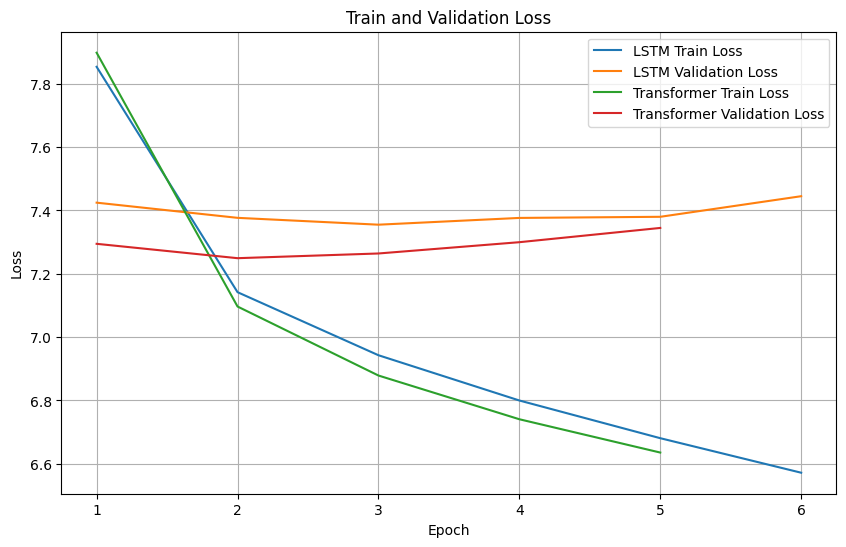

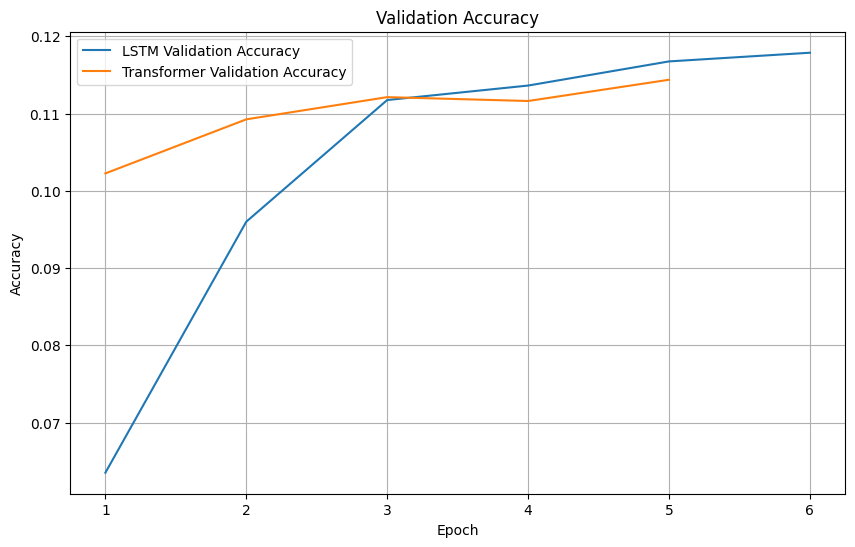

In [30]:
# ============================================================
# PLOTS
# ============================================================

lstm_epochs = range(
    1,
    len(lstm_history["train_loss"]) + 1
)

transformer_epochs = range(
    1,
    len(transformer_history["train_loss"]) + 1
)

# ============================================================
# LOSS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    lstm_epochs,
    lstm_history["train_loss"],
    label="LSTM Train Loss"
)

plt.plot(
    lstm_epochs,
    lstm_history["valid_loss"],
    label="LSTM Validation Loss"
)

plt.plot(
    transformer_epochs,
    transformer_history["train_loss"],
    label="Transformer Train Loss"
)

plt.plot(
    transformer_epochs,
    transformer_history["valid_loss"],
    label="Transformer Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train and Validation Loss")
plt.legend()
plt.grid()
# guardar figura
plt.savefig(r"../figures/train_validation_loss.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# VALIDATION ACCURACY
# ============================================================
plt.figure(figsize=(10, 6))

plt.plot(
    lstm_epochs,
    lstm_history["valid_acc"],
    label="LSTM Validation Accuracy"
)

plt.plot(
    transformer_epochs,
    transformer_history["valid_acc"],
    label="Transformer Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()
plt.grid()
# guardar figura
plt.savefig(r"../figures/validation_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()

## 1.5.9. Evaluación y comparación del rendimiento de los modelos

La tabla muestra los resultados de ambos modelos sobre los conjuntos de validación y test. 

El Transformer obtiene una menor pérdida de validación, siendo seleccionado como el mejor modelo, aunque ambas arquitecturas presentan valores de `accuracy` muy similares.

Los resultados son coherentes para con la dificultad de predecir la siguiente palabra exacta sobre un vocabulario de  más de 66.000 tokens con modelos de entre 5 y 6 millones de parámetros. Es de destacar que el LSTM supera ligeramente al Transformer en `Validation accuracy` con un coste computacional por época significativamente menor, lo que puede ser relevante en escenarios con recursos limitados.

In [32]:
criterion = nn.CrossEntropyLoss()

lstm_val_loss, lstm_val_acc = evaluate_model(
    lstm_model,
    valid_loader,
    criterion
)

lstm_test_loss, lstm_test_acc = evaluate_model(
    lstm_model,
    test_loader,
    criterion
)

tr_val_loss, tr_val_acc = evaluate_model(
    transformer_model,
    valid_loader,
    criterion
)

tr_test_loss, tr_test_acc = evaluate_model(
    transformer_model,
    test_loader,
    criterion
)

results = [
    ["LSTM", lstm_val_loss, lstm_val_acc, lstm_test_acc],
    ["Transformer", tr_val_loss, tr_val_acc, tr_test_acc]
]

print(
    tabulate(
        results,
        headers=["Modelo", "Validation Loss", "Validation Accuracy", "Test Accuracy"],
        tablefmt="grid",
        floatfmt=".4f"
    )
)

best_model_name = (
    "LSTM"
    if lstm_val_loss < tr_val_loss
    else "Transformer"
)

print(f"El mejor modelo de acuerdo a la pérdida de validación es: {best_model_name}")

+-------------+-------------------+-----------------------+-----------------+
| Modelo      |   Validation Loss |   Validation Accuracy |   Test Accuracy |
+=============+===================+=======================+=================+
| LSTM        |            7.3549 |                0.1118 |          0.1105 |
+-------------+-------------------+-----------------------+-----------------+
| Transformer |            7.2491 |                0.1092 |          0.1080 |
+-------------+-------------------+-----------------------+-----------------+
El mejor modelo de acuerdo a la perdida de validación es: Transformer


# 2. Visualización transformers
En esta parte vamos a visualizar los pesos de atención de las capas transformer para entender como funciona el contexto y la atención.


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">


**Ejercicio 3. Visualización sobre la cabeza de atención [1 pts.].**
En este ejercicio, el objetivo es representar los pesos de self-attention del modelo anterior y de otro modelo preentrenado. Las visualizaciones que se piden son (1) matriz de self attention y (2) token alignment. Estas dos visualizaciónes se pueden ver en la figura 1 izquierda arriba y figura 1 izquierda abajo de [ Interpretability analysis in transformers based on attention visualization](https://www.researchgate.net/publication/382296866_Interpretability_analysis_in_transformers_based_on_attention_visualization). Para ello, elige una frase de train y:
  1. Representa la matriz de atención para el modelo entrenado en el apartado anterior en su estado en la época 1 y en su estado en la época final. [0.4p]
  2. Repite lo mismo, pero ahora representando el token alignment. [0.4p]
  3. Escribe en dos líneas lo que observas. [0.2p]


Notas:
* Para entender mejor este tipo de visualizaciones se recomida ver el siguiente vídeo: [
Atención en los Transformers explicado visualmente](https://www.youtube.com/watch?v=eMlx5fFNoYc)
* Para realizar las representaciones visuales se puede utilizar cualquier tipo de libreria.
* Utiliza return_attentions=True en tu modelo para recuperar los pesos de la matriz de atención.


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
</div>

# 3. Modelos transformers fundacionales
A diferencia de las redes recurrentes, los modelos basados en Transformers tienen la capacidad de escalar en tamaño gracias a sus mecanismos de atención. Por eso, en la práctica, se pueden entrenar modelos muy profundos con billones de parámetros. Debido a esto, difícilmente un individuo o incluso la gran mayoría de empresas y grupos de investigación tienen las capacidades de entrar en estos modelos desde cero. Vamos a plantear cómo se realizaría en la práctica esto.

El objetivo de esta sección va ser tener el mejor modelo de análisis de sentimiento para IMBD basado en arquitecturas preentrenadas tipo Bert. Aquí, supon que tienes que **poner este modelo en producción**, para ello tienes que conseguir un **modelo con una accuracy suficientemente buena, pero también que sea rápido y eficiente**. Para ello exploraremos 4 enfoques distintos y complementarios en los ejercicios 4, 5, 6 y 7.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">


**Ejercicio 4. Finetuning downstream de un modelo pequeño [2 pts.].**
Este ejercicio debes tomar el modelo preentrenado [gaunernst/bert-mini-uncased](https://huggingface.co/gaunernst/bert-mini-uncased) de hugginface y entrenarlo para clasificar la base de datos [imbd](https://huggingface.co/datasets/stanfordnlp/imdb). Tanto el modelo como la base de datos los puedes descargar de forma automática de huggingface. Se pide:

1. Muestra en pantalla la estructura del modelo y el número de parámetros.
2. Modifica el modelo downstream para convertirlo en un modelo de clasificación. Toma las decisiones y suposiciones que consideres de forma debidamente justificada. Preprocesa la base de datos para poder entrenarla con el modelo.
3. Entrena el modelo de forma adecuada y completa.
4. Muestra las curvas de entrenamiento. Las gráficas deben ser claras e informativas.
5. Finalmente, muestra los resultados sobre el conjunto de test de tu mejor modelo.
6. Calcula cuanto tiempo cuesta hacer una inferencia sobre todo el conjunto de test.
7. Construye una tabla (imprimiendola adecuadamente con tabular) en la que se muestre el nombre del modelo, el número de parámetros, la accuracy sobre test y el tiempo de inferencia sobre todo el conjunto de test.



<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">

**Ejercicio 5. Finetuning downstream de un modelo grande congelando capas [1.5 pts.].**
Vamos a probar otra estrategia, para ver cuanta accuracy podemos obtener y entender como impacta el número de parámetros tanto en los tiempos de entrenamiento como en los tiempos de inferencia.

Este ejercicio debes tomar el modelo preentrenado [distilbert-base-uncased](https://huggingface.co/distilbert/distilbert-base-uncased) de hugginface y entrenarlo con los mismos datos que en el ejercicio 4.

Se pide:

1. Muestra en pantalla la estructura del modelo y el número de parámetros.
2. Entrenar todos los parámetros del modelo quizás sea innecesario. Una técnica es congelar parte de las capas del modelo y únicamente entrenar el resto. Congela el número de parámetros que consideres. Explica en dos lineas el motivo de tu elección.
3. Muestra en pantalla el número total de parámetros, los que están congelados y los que son entrenables.
4. Entrena el modelo de forma adecuada y completa.
5. Muestra las curvas de entrenamiento. Las gráficas deben ser claras e informativas.
6. Finalmente, muestra los resultados sobre el conjunto de test de tu mejor modelo.
7. Calcula cuanto tiempo cuesta hacer una inferencia sobre todo el conjunto de test.
8. Completa la tabla de resultados (la que se inició en el ejercicio 4) añadiendo este modelo y muestrala en pantalla.


Como referencia, en la Tabla 2 de [DistilBERT, a distilled version of BERT: smaller,
faster, cheaper and lighter](https://arxiv.org/pdf/1910.01108) se muestra la accuracy que se puede obtener con este modelo entrenando sobre esta base de datos. Al congelar capas quizás no obtengas esa accuracy, pero debes tomar tus decisiones para obtener accuracies cercanas a esa.




<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">


**Ejercicio 6. Modelo personalizado [1 pts.].**
Nuestro requisito es obtener tiempos de inferencia entre 5 y 10 veces más rápidos que los obtenidos para el modelo del ejercicio 4. Para ello:

1. Construye un modelo basado en el tipo de architectura Bert totalmente personalizado y desde cero (pesos del modelo aleatorios).
2. Este modelo debe tener alrededor de 5-6 Millones de parámetros como máximo y ser entre 5 y 10 veces más rápido en inferencia el modelo del ejercicio 4.
3. De forma similar, entrena el modelo de forma completa, muestra las curvas de entrenamiento, test, etc.
4. Actualiza la tabla de resultados con este modelo y muestrala en pantalla.

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
</div>

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">


**Ejercicio 7. Knowledge Distillation [1.5 pts.].**
El modelo del ejercicio 6, probablemente pueda mejorarse si en vez de aprender de los datos, aprende directamente del modelo grande del ejercicio 5. Para ello toma el modelo grande del ejercicio 5 como teacher y toma como student el modelo del ejercicio 6. El objetivo va a ser aplicar una ténica de knowledge distillation de forma que el modelo student en vez de aprender a predecir las etiquetas binarias del test de datos, intentará aprender los valores exactos de la última capa del modelo teacher.
Revisa algunos links para entender mejor como funciona un entrenamiento teacher-student:
* https://www.ibm.com/think/topics/knowledge-distillation
* https://labelyourdata.com/articles/machine-learning/knowledge-distillation
* https://docs.pytorch.org/tutorials/beginner/knowledge_distillation_tutorial.html


Se pide:

1. Monta un sistema de entrenamiento teacher student, en donde el modelo teacher es el modelo del ejericico 5 y el modelo student es el modelo del ejercicio 6 (una vez entrenado en el ejercicio 6).
2. Entrena el modelo student (controlando de forma adecuada el valor alpha) de forma que aprenda del modelo student. Mediante esta técnica deberas intentar que el modelo que ya estaba saturado al aprender directamente de los datos, sea capaz de aprender del modelo teacher y seguir mejorando la accuracy sobre test.
3. Muestra las curvas de entrenamiento, test, etc.
4. Actualiza la tabla de resultados con este modelo y muestrala en pantalla.
5. Haz una pequeña reflexión (3-4 líneas) sobre los ejercicio 4, 5, 6 y 7, señalando tus conclusiones, dificultades, ventajas, etc.

Nota. La complejidad del modelo student y la cantidad de datos es muy limitada por lo que puede ser dificil acertar con la estrategia de distillation adecuada para que el modelo student continue aprendiendo. Si no lo consiguieras, explica qué has intentado en tu reflexión.


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
</div>